## 1 导入

In [1]:
import os
import argparse
import yaml
import torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, PeftModel

## 2 设置参数

In [2]:
def load_config(config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
config = load_config("config.yaml")
config

{'model_dir': 'models/Qwen3-1.7B',
 'data_path': 'poetry_raw.jsonl',
 'processed_data_path': 'processed_dataset',
 'output_dir': './poetry_lora_output',
 'adapter_dir': './poetry_lora_adapter',
 'max_length': 1024,
 'system_prompt': '你是一个才华横溢的诗人，根据给定的创作背景生成一首诗词。',
 'model_name': 'Qwen/Qwen3-1.7B',
 'lora_r': 8,
 'lora_alpha': 16,
 'lora_dropout': 0.05,
 'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
 'num_epochs': 1,
 'batch_size': 1,
 'gradient_accumulation_steps': 4,
 'learning_rate': 0.0002,
 'logging_steps': 1,
 'save_steps': 50,
 'save_total_limit': 2,
 'seed': 42,
 'max_new_tokens': 1000,
 'temperature': 0.7,
 'top_p': 0.9,
 'test_backgrounds': ['背景：隆冬大雪，老友来访，围炉夜话，回忆往昔。', '背景：中秋月夜，游子漂泊异乡，望月思乡。']}

In [5]:
set_seed(config["seed"])

## 3 加载模型
 设置设备和量化

In [8]:
# 检测设备
use_gpu = torch.cuda.is_available()
print(f"GPU 可用: {use_gpu}")

# 加载 tokenizer
tokenizer = AutoTokenizer.from_pretrained(config["model_dir"], trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# 加载模型（根据设备选择量化）
if use_gpu:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )
    model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    fp16 = True
    print("模型加载至 GPU (4bit)")
else:
    model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        device_map="cpu",
        trust_remote_code=True,
        dtype=torch.float32
    )
    fp16 = False
    print("模型加载至 CPU (fp32)，请确保内存充足")


GPU 可用: False


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

模型加载至 CPU (fp32)，请确保内存充足


In [7]:
model

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
          (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
        (post_attention_layer

## 4 加载数据

In [8]:
model.config.use_cache = False

# 加载预处理数据集
dataset = load_from_disk(config["processed_data_path"])
print(f"数据集样本数: {len(dataset)}")

数据集样本数: 100


 ## 训练参数设置

In [9]:
# LoRA 配置
lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=config["lora_r"],
    lora_alpha=config["lora_alpha"],
    lora_dropout=config["lora_dropout"],
    target_modules=config["target_modules"],
    bias="none"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 3,211,264 || all params: 1,723,786,240 || trainable%: 0.1863


In [11]:
# 训练参数
training_args = TrainingArguments(
    output_dir=config["output_dir"],
    num_train_epochs=config["num_epochs"],
    per_device_train_batch_size=config["batch_size"],
    gradient_accumulation_steps=config["gradient_accumulation_steps"],
    learning_rate=config["learning_rate"],
    fp16=fp16,
    logging_steps=config["logging_steps"],
    save_steps=config["save_steps"],
    save_total_limit=config["save_total_limit"],
    remove_unused_columns=False,
    # report_to="tensorboard",
    # TENSORBOARD_LOGGING_DIR="./logs",
    seed=config["seed"],
    dataloader_pin_memory=False if not use_gpu else True,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=data_collator,
)

## 开始训练

In [12]:
print("\n开始训练...")
trainer.train()
print("训练完成")


开始训练...


Step,Training Loss
1,4.547688
2,4.503733
3,3.958099
4,3.615069
5,3.233476
6,3.497364
7,3.158080
8,3.203455
9,2.963220
10,2.825589


训练完成


LoRA adapter 已保存至 ./poetry_lora_adapter
Loss 曲线已保存至 training_loss2.png
训练日志已保存至 training_log.txt


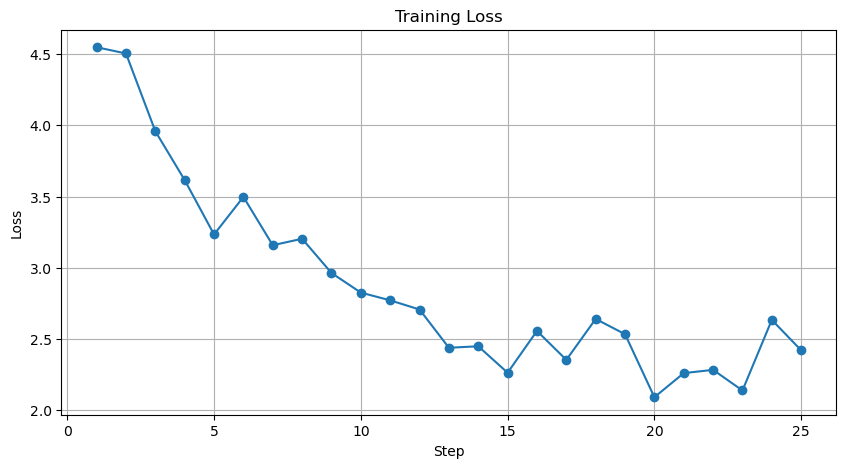

In [14]:
# 保存 LoRA adapter
model.save_pretrained(config["adapter_dir"])
tokenizer.save_pretrained(config["adapter_dir"])
print(f"LoRA adapter 已保存至 {config['adapter_dir']}")

# 绘制并保存 loss 曲线
log_history = trainer.state.log_history
losses = [e["loss"] for e in log_history if "loss" in e]
steps = [e["step"] for e in log_history if "loss" in e]
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.savefig("training_loss2.png")
print("Loss 曲线已保存至 training_loss2.png")

# 写入文本日志
with open("training_log2.txt", "w") as f:
    for s, l in zip(steps, losses):
        f.write(f"Step {s}: loss = {l:.6f}\n")
print("训练日志已保存至 training_log.txt")



## 测试

In [9]:
# ===== 验证生成 =====
# del model
if use_gpu:
    torch.cuda.empty_cache()

# 重新加载基础模型和 adapter 用于推理
if use_gpu:
    base_model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        config["model_dir"],
        device_map="cpu",
        trust_remote_code=True,
        dtype=torch.float32
    )
model = PeftModel.from_pretrained(base_model, config["adapter_dir"])
print("加载训练好的 LoRA 模型用于验证")

generation_config = {
    "max_new_tokens": config["max_new_tokens"],
    "temperature": config["temperature"],
    "top_p": config["top_p"],
    "do_sample": True,
    "eos_token_id": tokenizer.eos_token_id,
    "pad_token_id": tokenizer.pad_token_id,
}

results = []
for bg in config["test_backgrounds"]:
    messages = [
        {"role": "system", "content": config["system_prompt"]},
        {"role": "user", "content": bg}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, **generation_config)
    answer = tokenizer.decode(outputs[0], skip_special_tokens=False)[len(prompt):].strip()
    results.append(f"背景：{bg}\n生成诗词：\n{answer}\n")
    print(f"\n背景：{bg}\n生成诗词：\n{answer}")

with open("generated_poems.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(results))
print("验证结果已保存至 generated_poems.txt")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

加载训练好的 LoRA 模型用于验证

背景：背景：隆冬大雪，老友来访，围炉夜话，回忆往昔。
生成诗词：
<think>
好的，用户让我写一首诗，背景是隆冬大雪，老友来访，围炉夜话，回忆往昔。首先，我需要确定诗的结构和形式。用户可能希望是一首古典诗词，比如七言律诗或者绝句，但考虑到内容有回忆和情感，可能更适合古风或者词牌。

接下来，分析场景：隆冬大雪，老友来访，围炉夜话。这需要营造出寒冷中的温馨氛围，以及回忆往昔的温情。要注意季节的寒冷与温暖的对比，以及时间的流逝。

然后，考虑意象的选择。雪、炉火、旧友、回忆、往事等。需要将这些元素融入诗中，同时保持语言的优美和押韵。可能需要使用对仗和比喻，比如将雪比作玉屑，炉火映照往事。

还要注意情感的表达，既有对过去的怀念，也有对现在温暖的感慨。可能需要通过对比手法，如寒冷与温暖，过去与现在，来增强情感层次。

然后，构思诗句的结构。比如，首联点明时间和场景，颔联和颈联展开回忆和情感，尾联收束全诗，表达情感。押韵方面，选择平仄合适的韵脚，使诗歌流畅。

需要注意避免陈词滥调，用新颖的比喻和意象。比如“雪絮如酥”是常见的，但可以稍作变化，或者用其他比喻。同时，保持语言的凝练，避免冗长。

最后检查是否符合用户的需求，是否有遗漏的元素，情感是否到位，结构是否合理。可能需要调整用词和句式，使整体更协调，意境更深远。
</think>

《冬夜寄友》
雪絮如酥落满庭，寒炉煨芋暖衣轻。
旧时携手春江月，今夕同言夜雪星。
玉屑无声藏旧事，冰纹有味印残灯。
谁将往事拈花问，一笑拈将万古情。

注：此诗以冬夜围炉为背景，通过雪絮、炉火、旧事等意象勾勒出往昔温情。首联以雪景点明时节，颔联以春江月夜与夜雪星图景形成时空对照。颈联用玉屑、冰纹等意象隐喻往事，尾联以拈花问情收束全篇，将寒夜温情与岁月流转熔铸成永恒之境。全诗以冷暖对照、今昔互映的笔法，展现岁月沉淀的深情。<|im_end|>

背景：背景：中秋月夜，游子漂泊异乡，望月思乡。
生成诗词：
<think>
好的，我现在要处理用户的请求，生成一首中秋月夜的诗词，主题是游子漂泊异乡，望月思乡。首先，我需要确定诗词的风格和情感基调。中秋夜，月亮是主要意象，思乡之情是核心。用户希望是才华横溢的诗人，所以得用古典诗词的格式，可能选七言律诗或绝句，但考虑到中秋的意境，可能更适合词牌，比如《水调歌头